# Uber NYC Pickups — Time Series Forecast (Hourly)
## Trend → Seasonality → Cycles → Hybrid Boosted Model (LR + XGBoost)

**Key design decisions (informed by Kaggle solutions):**
- **Hourly aggregation** instead of daily → captures intraday demand peaks, gives ~4 400 observations
- **Rich time features**: hour-of-day, is_rush_hour, is_weekend + cyclical sin/cos encodings
- **Natural lags for ride-hailing**: `lag_1` (1 h ago), `lag_24` (yesterday same hour), `lag_168` (last week same hour)
- **Hybrid design**: LR handles trend extrapolation; XGBoost learns all seasonality + cycles from residuals
- **Walk-forward CV** with 5 weekly test windows for reliable RMSE estimation

---

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.signal import periodogram as scipy_periodogram
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-darkgrid')
plot_params = dict(
    color='0.75', style='.', markeredgecolor='0.25',
    markerfacecolor='0.25', legend=False,
)

## 1. Load Data
Merge the six monthly raw files (Apr–Sep 2014).  
Each row = one pickup with `Date/Time`, `Lat`, `Lon`, `Base`.

In [25]:
DATA_DIR = Path(r"C:/Users/Elias/.cache/kagglehub/datasets/fivethirtyeight/uber-pickups-in-new-york-city/versions/2")

files_2014 = [
    'uber-raw-data-apr14.csv', 'uber-raw-data-may14.csv',
    'uber-raw-data-jun14.csv', 'uber-raw-data-jul14.csv',
    'uber-raw-data-aug14.csv', 'uber-raw-data-sep14.csv',
]

dfs = [pd.read_csv(DATA_DIR / f) for f in files_2014]
raw = pd.concat(dfs, ignore_index=True)
print(f'Raw rows: {raw.shape[0]:,}  |  Columns: {raw.columns.tolist()}')
raw.head(3)

Raw rows: 4,534,327  |  Columns: ['Date/Time', 'Lat', 'Lon', 'Base']


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512


## 2. Data Cleaning

Four steps:
1. **Datetime parsing** — `'M/D/YYYY H:MM:SS'` → `datetime64`
2. **NaN audit**
3. **GPS bounding box** — drop pickups outside NYC (bad sensor readings)
4. **Hourly aggregation** — `floor('h')` + `reindex` full range (fills quiet overnight hours with 0)
5. **Outlier clipping** — IQR on hourly counts (clip, never drop — preserves continuity)

In [26]:
# 1 & 2 — datetime + NaN
raw['Date/Time'] = pd.to_datetime(raw['Date/Time'])
print('NaN counts:')
print(raw.isna().sum())
print(f'\nDate range: {raw["Date/Time"].min()}  to  {raw["Date/Time"].max()}')

NaN counts:
Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

Date range: 2014-04-01 00:00:00  to  2014-09-30 22:59:00


In [27]:
# 3 — GPS bounding box (NYC: lat 40.4-41.0, lon -74.3 to -73.6)
mask = (
    raw['Lat'].between(40.4, 41.0)
    & raw['Lon'].between(-74.3, -73.6)
    & raw['Date/Time'].notna()
)
n_bad = (~mask).sum()
print(f'Removed {n_bad:,} rows with invalid coordinates ({n_bad/len(raw)*100:.2f}%)')
raw = raw[mask].reset_index(drop=True)

Removed 17,665 rows with invalid coordinates (0.39%)


In [28]:
# 4 — Hourly aggregation
raw['Hour'] = raw['Date/Time'].dt.floor('h')
uber = raw.groupby('Hour').size().rename('Pickups')

# Reindex to fill hours with zero pickups (typically late-night gaps)
full_idx = pd.date_range(uber.index.min(), uber.index.max(), freq='h')
uber = uber.reindex(full_idx, fill_value=0)
uber.index.name = 'Hour'

print(f'Hourly observations: {len(uber):,}')
print(f'Period : {uber.index[0]}  to  {uber.index[-1]}')
print(f'Zero-pickup hours: {(uber == 0).sum()} ({(uber == 0).mean()*100:.1f}%)')
uber.head()

Hourly observations: 4,391
Period : 2014-04-01 00:00:00  to  2014-09-30 22:00:00
Zero-pickup hours: 0 (0.0%)


Hour
2014-04-01 00:00:00    138
2014-04-01 01:00:00     66
2014-04-01 02:00:00     52
2014-04-01 03:00:00     93
2014-04-01 04:00:00    166
Freq: h, Name: Pickups, dtype: int64

IQR fence: [-912, 2844]   |   outliers: 34


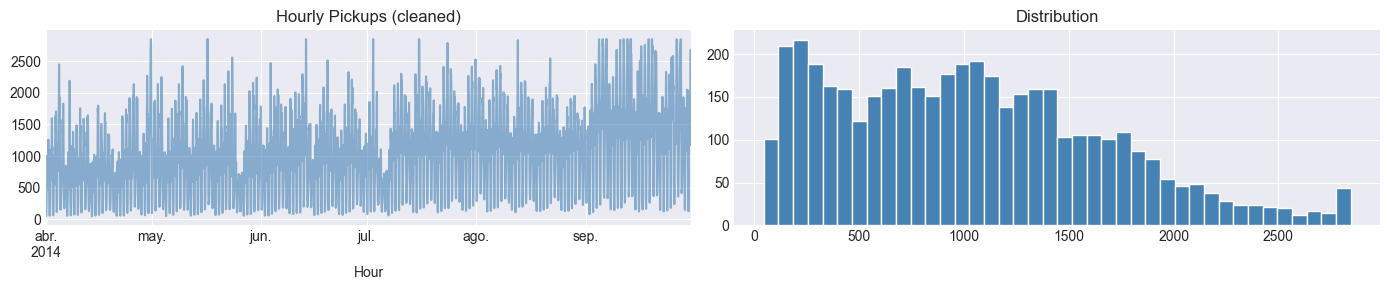

In [29]:
# 5 — Outlier detection on hourly counts (IQR)
Q1, Q3 = uber.quantile(0.25), uber.quantile(0.75)
IQR = Q3 - Q1
lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

n_out = ((uber < lo) | (uber > hi)).sum()
print(f'IQR fence: [{lo:.0f}, {hi:.0f}]   |   outliers: {n_out}')
uber = uber.clip(lower=lo, upper=hi)   # clip preserves index continuity

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
uber.plot(ax=axes[0], color='steelblue', alpha=0.6, title='Hourly Pickups (cleaned)')
uber.hist(ax=axes[1], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution')
plt.tight_layout(); plt.show()

y = uber.copy()

## 3. Trend Analysis

We use a **168-hour (1 week) moving average** — large enough to smooth both the daily (24 h) and weekly (168 h) seasonality, leaving only the long-term trend.

| Moving average shape | Action |
|---|---|
| Straight line | `order=1` (linear) |
| Curved | `order=2` (quadratic) |
| Flat | No trend needed |

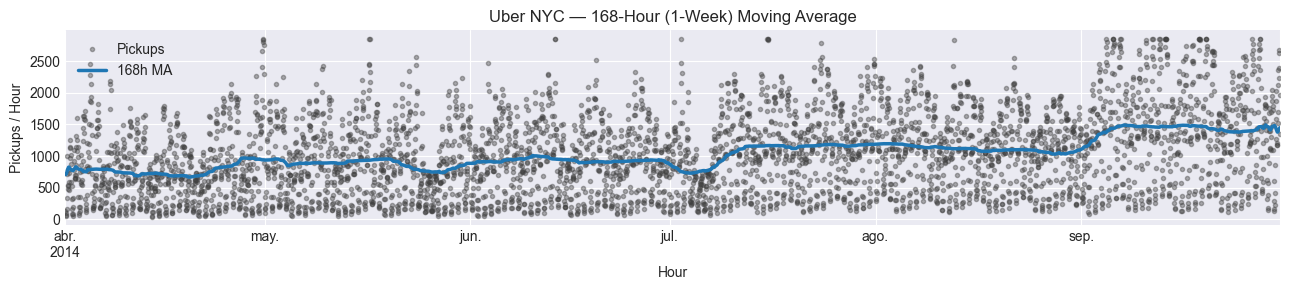

In [30]:
ma = y.rolling(window=168, center=True, min_periods=84).mean()

fig, ax = plt.subplots(figsize=(13, 3))
y.plot(ax=ax, **plot_params, alpha=0.4)
ma.plot(ax=ax, linewidth=2.5, color='C0',
        title='Uber NYC — 168-Hour (1-Week) Moving Average', label='168h MA')
ax.set_ylabel('Pickups / Hour')
ax.legend(); plt.tight_layout(); plt.show()

Trend: +0.1567 pickups/hour per hour
Intercept: 683.2


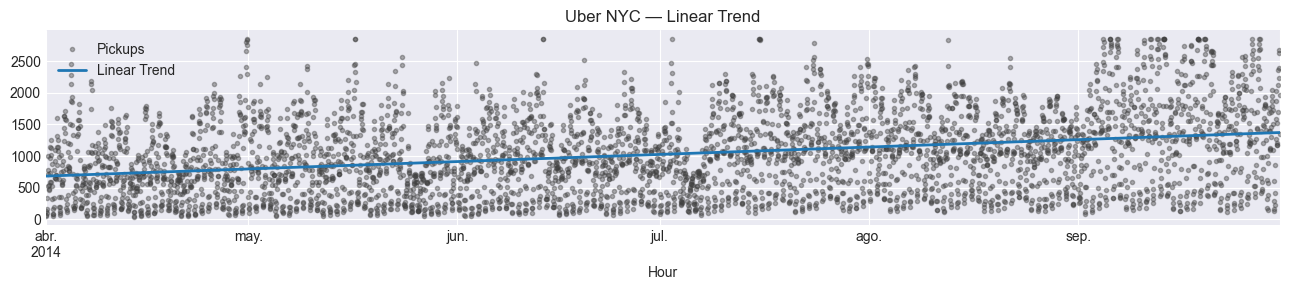

In [31]:
# LR fits ONLY the linear trend (time step variable)
# Everything else — seasonality + cycles — will be learned by XGBoost
time_idx = np.arange(len(y))
X_lr_full = pd.DataFrame({'const': 1.0, 'trend': time_idx}, index=y.index)

model_trend = LinearRegression(fit_intercept=False)
model_trend.fit(X_lr_full, y)
y_trend = pd.Series(model_trend.predict(X_lr_full), index=y.index, name='Trend')

print(f'Trend: {model_trend.coef_[1]:+.4f} pickups/hour per hour')
print(f'Intercept: {model_trend.coef_[0]:.1f}')

fig, ax = plt.subplots(figsize=(13, 3))
y.plot(ax=ax, **plot_params, alpha=0.4)
y_trend.plot(ax=ax, linewidth=2, color='C0', label='Linear Trend')
ax.set_title('Uber NYC — Linear Trend')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Seasonality

With **hourly data** the periodogram can resolve two distinct seasonal frequencies:

| Frequency | Interpretation | Feature strategy |
|---|---|---|
| Daily (365 cycles/year) | Rush hours vs. quiet nights | `hour` + `is_rush_am/pm` + cyclical sin/cos |
| Weekly (52 cycles/year) | Weekday vs. weekend pattern | `dayofweek` + `is_weekend` |

> In v1 (daily aggregation) the daily cycle was **invisible** — we only saw the weekly peak.

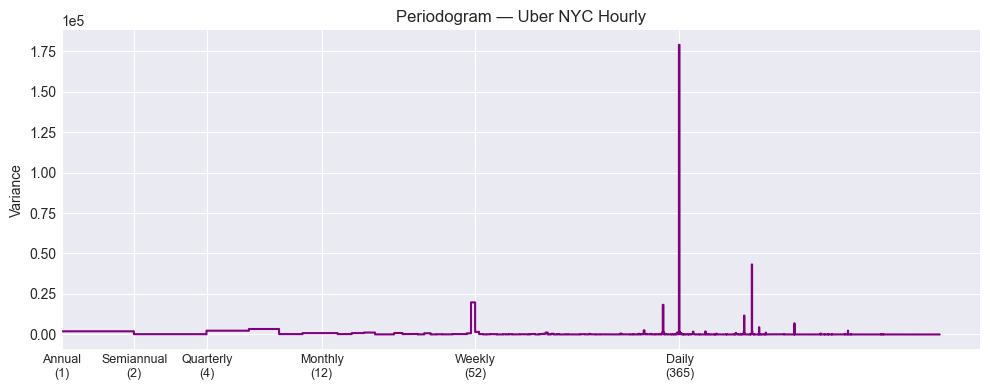

In [32]:
def plot_periodogram(ts, detrend='linear', ax=None):
    """Periodogram for hourly series: x-axis = cycles per year."""
    fs = pd.Timedelta('365D') / pd.Timedelta('1h')   # 8 760 samples/year
    freqs, spectrum = scipy_periodogram(
        ts.values, fs=fs, detrend=detrend, window='boxcar', scaling='spectrum'
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqs, spectrum, color='purple')
    ax.set_xscale('log')
    ax.set_xticks([1, 2, 4, 12, 52, 365])
    ax.set_xticklabels(
        ['Annual\n(1)', 'Semiannual\n(2)', 'Quarterly\n(4)',
         'Monthly\n(12)', 'Weekly\n(52)', 'Daily\n(365)'],
        fontsize=9,
    )
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_ylabel('Variance'); ax.set_title('Periodogram — Uber NYC Hourly')
    return ax

fig, ax = plt.subplots(figsize=(10, 4))
plot_periodogram(y, ax=ax)
plt.tight_layout(); plt.show()

# Expected: two dominant peaks — Daily(365) and Weekly(52)
# This confirms we need hour-of-day AND day-of-week features

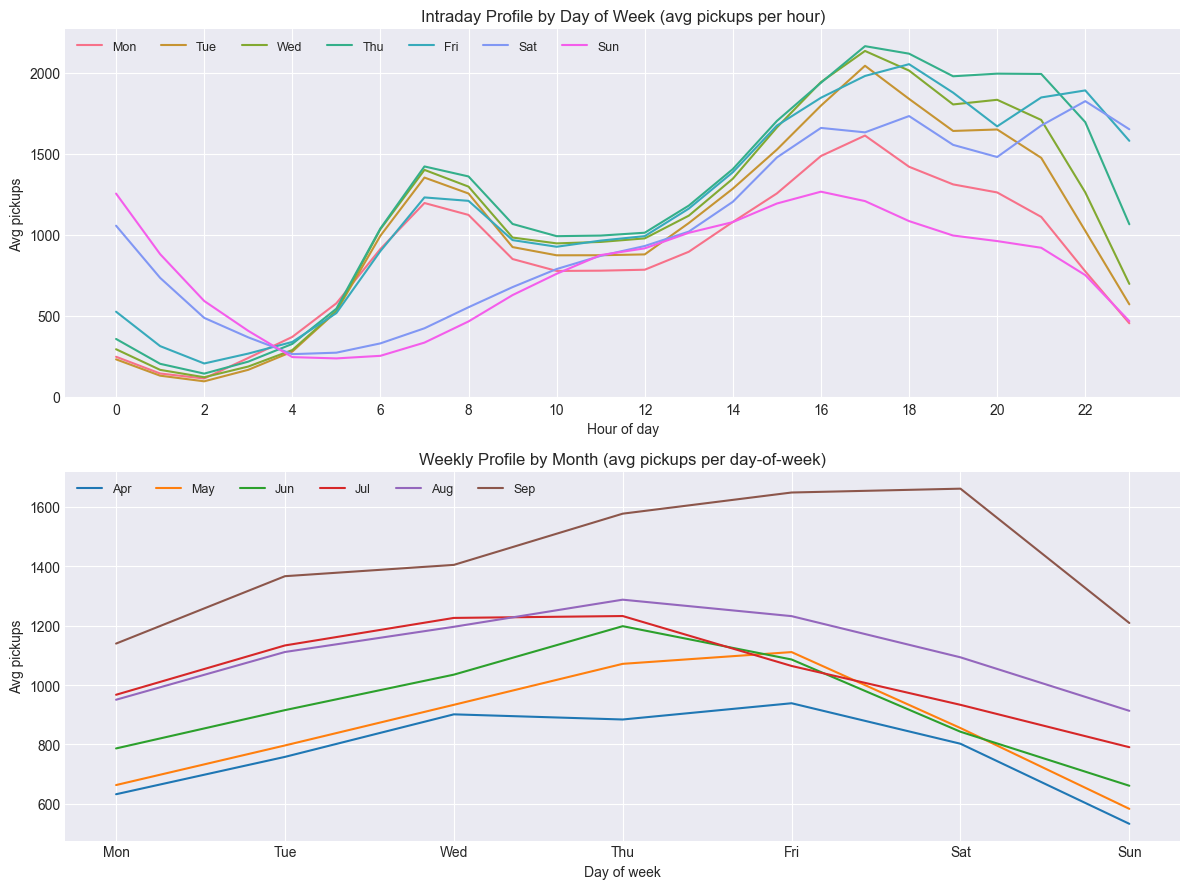

In [33]:
# Seasonal plots — one panel per seasonality level
X_s = pd.DataFrame({
    'Pickups':   y.values,
    'hour':      y.index.hour,
    'dayofweek': y.index.dayofweek,
    'week':      y.index.isocalendar().week.astype(int),
    'month':     y.index.month,
}, index=y.index)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 9))

# Plot 1: Average pickups by hour, split by day-of-week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
palette = sns.color_palette('husl', 7)
for dow, color in zip(range(7), palette):
    subset = X_s[X_s['dayofweek'] == dow].groupby('hour')['Pickups'].mean()
    subset.plot(ax=ax0, color=color, label=day_labels[dow], linewidth=1.5)
ax0.set_title('Intraday Profile by Day of Week (avg pickups per hour)')
ax0.set_xlabel('Hour of day'); ax0.set_ylabel('Avg pickups')
ax0.set_xticks(range(0, 24, 2))
ax0.legend(ncol=7, fontsize=9)

# Plot 2: Average pickups by day-of-week, split by month
month_labels = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep'}
palette2 = sns.color_palette('tab10', 6)
for m, color in zip(range(4, 10), palette2):
    subset = X_s[X_s['month'] == m].groupby('dayofweek')['Pickups'].mean()
    subset.plot(ax=ax1, color=color, label=month_labels[m], linewidth=1.5)
ax1.set_title('Weekly Profile by Month (avg pickups per day-of-week)')
ax1.set_xlabel('Day of week'); ax1.set_ylabel('Avg pickups')
ax1.set_xticks(range(7)); ax1.set_xticklabels(day_labels)
ax1.legend(ncol=6, fontsize=9)

plt.tight_layout(); plt.show()

## 5. Serial Dependence & Cycles

After removing the linear trend, remaining residuals contain both seasonality and serial dependence.  
The **PACF** shows which lags carry genuinely new information beyond what shorter lags already explain.

For ride-hailing, three lags have strong physical meaning:

| Lag | Meaning |
|---|---|
| `lag_1` | 1 hour ago — short-term momentum |
| `lag_24` | Same hour yesterday — daily pattern |
| `lag_168` | Same hour last week — weekly pattern |

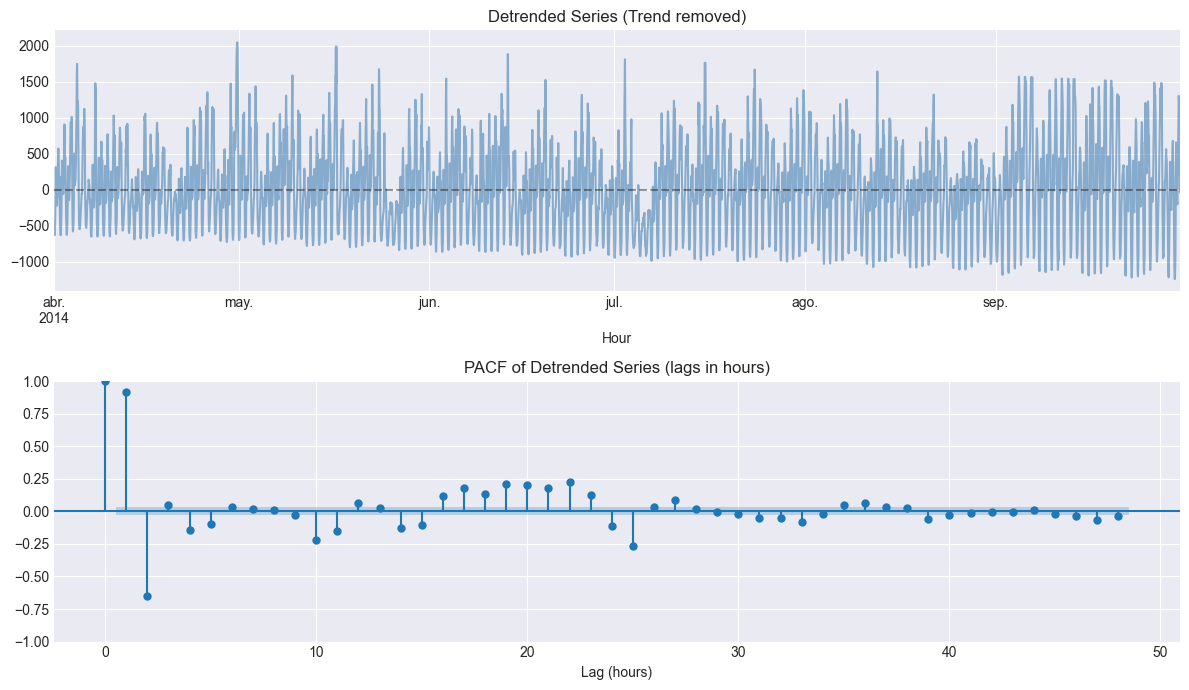

Expected: significant spikes at lag 1, lag 24, and possibly lag 48


In [34]:
y_detrended = (y - y_trend).rename('Detrended')

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
y_detrended.plot(ax=axes[0], color='steelblue', alpha=0.6,
                 title='Detrended Series (Trend removed)')
axes[0].axhline(0, color='k', linestyle='--', alpha=0.4)

# PACF up to 48 lags (2 days) to see lag_24 significance
plot_pacf(y_detrended.values, lags=48, ax=axes[1],
          title='PACF of Detrended Series (lags in hours)')
axes[1].set_xlabel('Lag (hours)')
plt.tight_layout(); plt.show()

print('Expected: significant spikes at lag 1, lag 24, and possibly lag 48')

## 6. Feature Engineering

Two feature sets — one per model in the hybrid:

| Feature set | Used by | Purpose |
|---|---|---|
| `X_lr` — `const` + `trend` | LinearRegression | Captures long-term growth (extrapolatable) |
| `X_xgb` — time + lag + rolling | XGBoost | Captures all seasonality + serial dependence |

**Cyclical encoding** (`hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`) tells the model that 23:00 is adjacent to 00:00 — a linear `hour` column cannot express this.

In [35]:
def make_time_features(idx):
    """Calendar features + cyclical sin/cos encoding."""
    return pd.DataFrame({
        # Raw categorical
        'hour':        idx.hour,
        'dayofweek':   idx.dayofweek,
        'month':       idx.month,
        # Boolean flags (domain knowledge for ride-hailing)
        'is_weekend':  (idx.dayofweek >= 5).astype(int),
        'is_rush_am':  ((idx.hour >= 7)  & (idx.hour <= 9)).astype(int),
        'is_rush_pm':  ((idx.hour >= 17) & (idx.hour <= 19)).astype(int),
        # Cyclical encoding: captures 23->0 continuity for trees and linear models
        'hour_sin':    np.sin(2 * np.pi * idx.hour / 24),
        'hour_cos':    np.cos(2 * np.pi * idx.hour / 24),
        'dow_sin':     np.sin(2 * np.pi * idx.dayofweek / 7),
        'dow_cos':     np.cos(2 * np.pi * idx.dayofweek / 7),
    }, index=idx)


def make_lag_features(ts, lags):
    """Shift ts by each lag (lead_time=1 baked into the lag list)."""
    return pd.concat({f'lag_{l}': ts.shift(l) for l in lags}, axis=1)


def make_rolling_features(ts, windows):
    """Rolling means shifted by 1 to avoid leakage."""
    return pd.concat(
        {f'roll_{w}h': ts.shift(1).rolling(w).mean() for w in windows}, axis=1
    )


# ── Build both feature matrices ────────────────────────────────────────────
X_lr_full = pd.DataFrame(
    {'const': 1.0, 'trend': np.arange(len(y))}, index=y.index
)

X_xgb_full = pd.concat([
    make_time_features(y.index),
    make_lag_features(y,  lags=[1, 24, 48, 168]),    # 1h, 1day, 2days, 1week
    make_rolling_features(y, windows=[24, 168]),      # 24h and weekly rolling mean
], axis=1)

# Drop rows where any lag/rolling is NaN (first 168 rows = first week)
valid_idx   = X_xgb_full.dropna().index
X_lr        = X_lr_full.loc[valid_idx]
X_xgb       = X_xgb_full.loc[valid_idx]
y_aligned   = y.loc[valid_idx]

print(f'Observations after alignment: {len(valid_idx):,}  (dropped first {len(y)-len(valid_idx)} rows)')
print(f'X_lr shape : {X_lr.shape}')
print(f'X_xgb shape: {X_xgb.shape}')
print(f'XGB features: {X_xgb.columns.tolist()}')

Observations after alignment: 4,223  (dropped first 168 rows)
X_lr shape : (4223, 2)
X_xgb shape: (4223, 16)
XGB features: ['hour', 'dayofweek', 'month', 'is_weekend', 'is_rush_am', 'is_rush_pm', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1', 'lag_24', 'lag_48', 'lag_168', 'roll_24h', 'roll_168h']


## 7. Hybrid Boosted Model

```
y  =  trend  +  (seasonality + cycles + noise)
       └─LR─┘   └──────────────XGBoost──────────┘
```

**Why this split?** XGBoost predicts the mean of training buckets → it cannot extrapolate a growing trend beyond training data. LinearRegression CAN extrapolate (it's a mathematical function). XGBoost is powerful for the non-linear patterns that the linear trend leaves behind.

**Walk-forward CV** — `TimeSeriesSplit(n_splits=5, test_size=168)`:  
Five independent **1-week test windows**, training set expands each fold.
```
Fold 1:  train ██████████████░░░░░░░  test ░░░ (week 1)
Fold 2:  train █████████████████░░░  test ░░░ (week 2)
Fold 3:  train ██████████████████░░  test ░░░ (week 3)
Fold 4:  train ███████████████████░  test ░░░ (week 4)
Fold 5:  train ████████████████████  test ░░░ (week 5)
```

In [36]:
def evaluate(y_true, y_pred):
    err  = np.array(y_true) - np.array(y_pred)
    rmse = np.sqrt(np.mean(err ** 2))
    mae  = np.mean(np.abs(err))
    # MAPE: skip near-zero hours (late night with 0-1 pickups)
    mask = np.array(y_true) > 5
    mape = np.mean(np.abs(err[mask] / np.array(y_true)[mask])) * 100 if mask.sum() else np.nan
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((np.array(y_true) - np.mean(y_true)) ** 2)
    r2   = 1 - ss_res / ss_tot
    return {'RMSE': round(rmse, 1), 'MAE': round(mae, 1),
            'MAPE%': round(mape, 2) if not np.isnan(mape) else None, 'R2': round(r2, 3)}


XGB_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.05, reg_lambda=1.0,
    random_state=42, verbosity=0,
)

tscv = TimeSeriesSplit(n_splits=5, test_size=168)   # 5 x 1-week windows

cv_rows, fold_preds = [], []

for fold, (tr, te) in enumerate(tscv.split(X_lr), start=1):
    Xlr_tr,  Xlr_te  = X_lr.iloc[tr],  X_lr.iloc[te]
    Xxgb_tr, Xxgb_te = X_xgb.iloc[tr], X_xgb.iloc[te]
    y_tr,    y_te    = y_aligned.iloc[tr], y_aligned.iloc[te]

    # Step A — LR on trend
    lr = LinearRegression(fit_intercept=False)
    lr.fit(Xlr_tr, y_tr)
    yhat_lr_tr = pd.Series(lr.predict(Xlr_tr), index=y_tr.index)
    yhat_lr_te = pd.Series(lr.predict(Xlr_te), index=y_te.index)

    # Step B — XGBoost on detrended residuals (all seasonal + serial patterns)
    resid_tr = y_tr - yhat_lr_tr
    xgb = XGBRegressor(**XGB_PARAMS)
    xgb.fit(Xxgb_tr, resid_tr)
    yhat_xgb_te = pd.Series(xgb.predict(Xxgb_te), index=y_te.index)

    # Step C — Combine
    yhat       = yhat_lr_te + yhat_xgb_te
    m_hybrid   = evaluate(y_te, yhat)
    m_lr       = evaluate(y_te, yhat_lr_te)

    cv_rows.append({
        'Fold': fold,
        'Train hrs': len(tr), 'Test start': str(y_te.index[0])[:13],
        'RMSE Hybrid': m_hybrid['RMSE'], 'MAE Hybrid': m_hybrid['MAE'],
        'MAPE% Hybrid': m_hybrid['MAPE%'], 'R2 Hybrid': m_hybrid['R2'],
        'RMSE LR': m_lr['RMSE'],
    })
    fold_preds.append({'fold': fold, 'y_true': y_te,
                       'y_hat': yhat, 'y_lr': yhat_lr_te})

cv_df = pd.DataFrame(cv_rows).set_index('Fold')
print(cv_df.to_string())
print(f'\nMean across folds:')
print(f'  Hybrid RMSE  : {cv_df["RMSE Hybrid"].mean():.1f} pickups/hour')
print(f'  LR base RMSE : {cv_df["RMSE LR"].mean():.1f} pickups/hour')
print(f'  Hybrid R2    : {cv_df["R2 Hybrid"].mean():.3f}')

      Train hrs     Test start  RMSE Hybrid  MAE Hybrid  MAPE% Hybrid  R2 Hybrid  RMSE LR
Fold                                                                                     
1          3383  2014-08-26 23        130.2        98.0         15.07      0.936    530.4
2          3551  2014-09-02 23        178.2       142.6         15.41      0.949    838.9
3          3719  2014-09-09 23        150.0       111.3         10.55      0.965    833.7
4          3887  2014-09-16 23        134.4        94.8          8.97      0.970    785.5
5          4055  2014-09-23 23        170.3       142.8         15.64      0.947    745.0

Mean across folds:
  Hybrid RMSE  : 152.6 pickups/hour
  LR base RMSE : 746.7 pickups/hour
  Hybrid R2    : 0.953


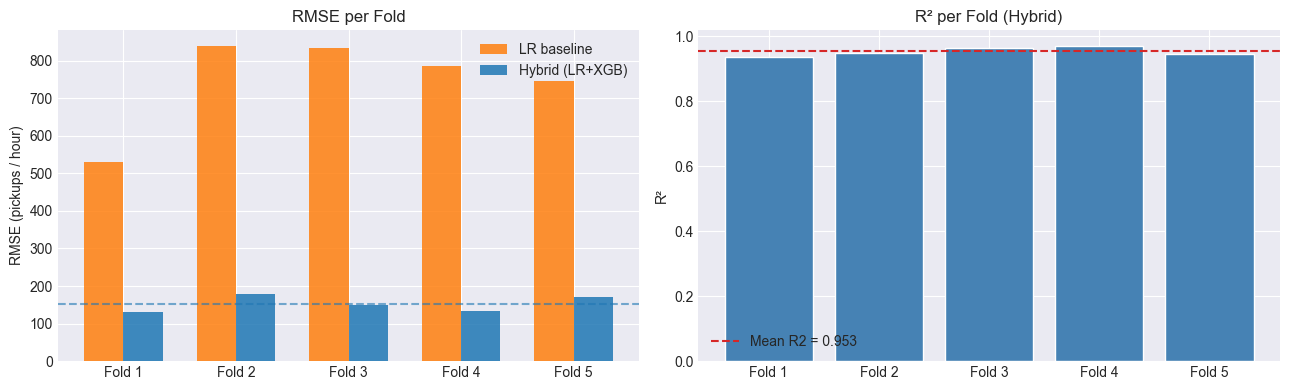

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(cv_df))
w = 0.35
axes[0].bar(x - w/2, cv_df['RMSE LR'],     w, label='LR baseline', color='C1', alpha=0.85)
axes[0].bar(x + w/2, cv_df['RMSE Hybrid'], w, label='Hybrid (LR+XGB)', color='C0', alpha=0.85)
axes[0].axhline(cv_df['RMSE Hybrid'].mean(), color='C0', linestyle='--', alpha=0.6)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'Fold {i}' for i in cv_df.index])
axes[0].set_ylabel('RMSE (pickups / hour)'); axes[0].set_title('RMSE per Fold')
axes[0].legend()

axes[1].bar(x, cv_df['R2 Hybrid'], color='steelblue', edgecolor='white')
axes[1].axhline(cv_df['R2 Hybrid'].mean(), color='C3', linestyle='--',
                label=f'Mean R2 = {cv_df["R2 Hybrid"].mean():.3f}')
axes[1].set_xticks(x); axes[1].set_xticklabels([f'Fold {i}' for i in cv_df.index])
axes[1].set_ylabel('R²'); axes[1].set_title('R² per Fold (Hybrid)')
axes[1].legend()
plt.tight_layout(); plt.show()

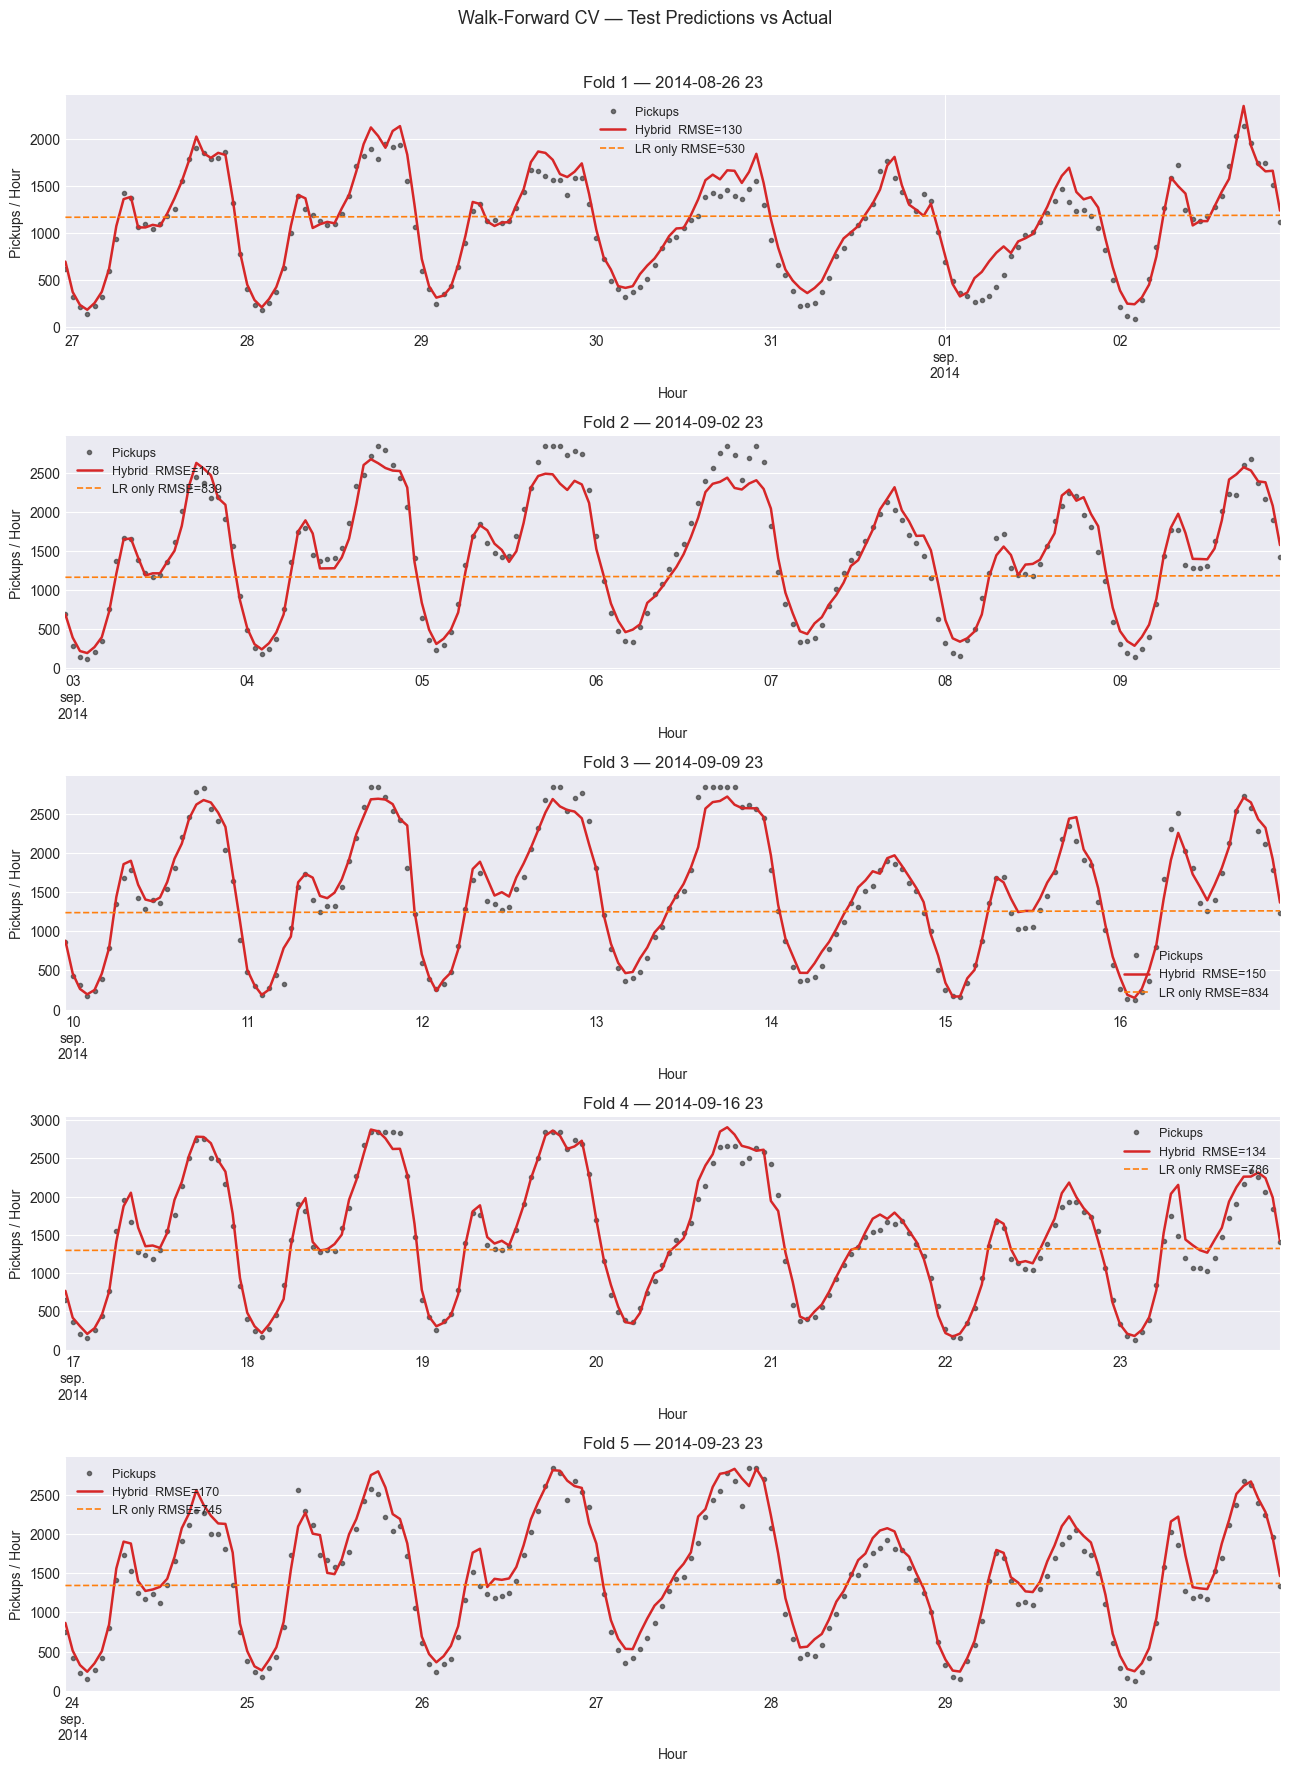

In [38]:
fig, axes = plt.subplots(len(fold_preds), 1,
                          figsize=(13, 3.5 * len(fold_preds)), sharex=False)
if len(fold_preds) == 1: axes = [axes]

for fp, ax in zip(fold_preds, axes):
    fp['y_true'].plot(ax=ax, **plot_params, alpha=0.7)
    fp['y_hat'].plot(ax=ax, linewidth=1.8, color='C3',
                     label=f'Hybrid  RMSE={cv_df.loc[fp["fold"],"RMSE Hybrid"]:.0f}')
    fp['y_lr'].plot(ax=ax, linewidth=1.2, color='C1', linestyle='--',
                    label=f'LR only RMSE={cv_df.loc[fp["fold"],"RMSE LR"]:.0f}')
    ax.set_title(f'Fold {fp["fold"]} — {cv_df.loc[fp["fold"],"Test start"]}')
    ax.set_ylabel('Pickups / Hour'); ax.legend(fontsize=9)

plt.suptitle('Walk-Forward CV — Test Predictions vs Actual', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

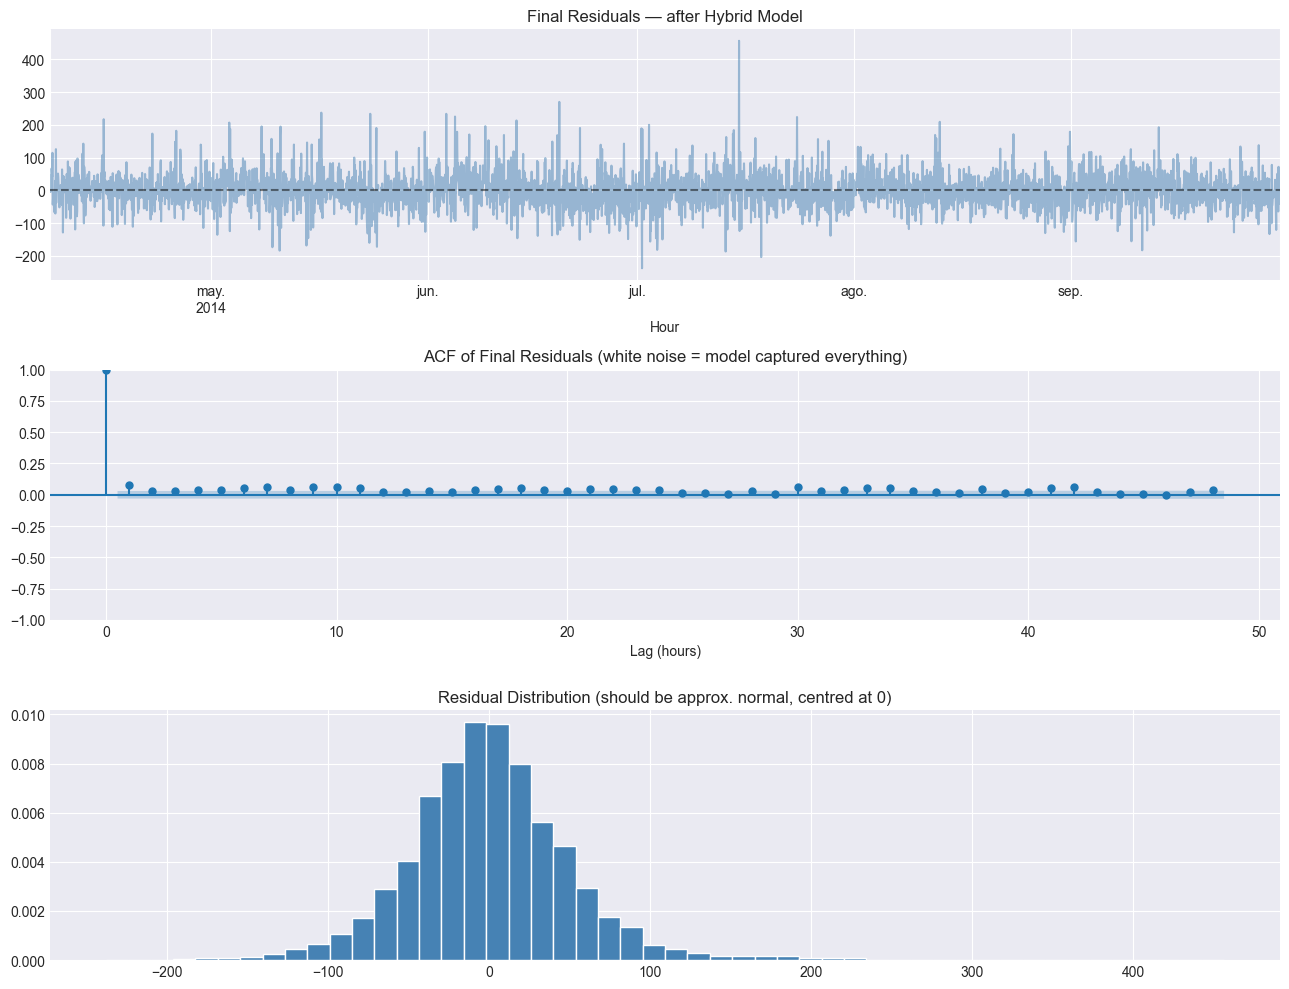

Ljung-Box test:
        lb_stat     lb_pvalue
24   202.202657  3.916268e-30
48   314.476243  7.741497e-41
168  570.265699  3.088412e-45

p-value > 0.05 -> cannot reject H0 (white noise) -> model is well-specified


In [39]:
# Final model trained on ALL aligned data
lr_f = LinearRegression(fit_intercept=False)
lr_f.fit(X_lr, y_aligned)
resid_all = y_aligned - pd.Series(lr_f.predict(X_lr), index=y_aligned.index)

xgb_f = XGBRegressor(**XGB_PARAMS)
xgb_f.fit(X_xgb, resid_all)

y_fitted    = pd.Series(lr_f.predict(X_lr), index=y_aligned.index) \
            + pd.Series(xgb_f.predict(X_xgb), index=y_aligned.index)
final_resid = (y_aligned - y_fitted).rename('Final Residuals')

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Residual time plot
final_resid.plot(ax=axes[0], color='steelblue', alpha=0.5,
                 title='Final Residuals — after Hybrid Model')
axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)

# ACF — should look like white noise (all bars inside CI)
plot_acf(final_resid.values, lags=48, ax=axes[1],
         title='ACF of Final Residuals (white noise = model captured everything)')
axes[1].set_xlabel('Lag (hours)')

# Distribution
axes[2].hist(final_resid, bins=50, color='steelblue', edgecolor='white', density=True)
axes[2].set_title('Residual Distribution (should be approx. normal, centred at 0)')
plt.tight_layout(); plt.show()

# Ljung-Box test: H0 = residuals are white noise
lb = acorr_ljungbox(final_resid.values, lags=[24, 48, 168], return_df=True)
print('Ljung-Box test:')
print(lb.to_string())
print('\np-value > 0.05 -> cannot reject H0 (white noise) -> model is well-specified')

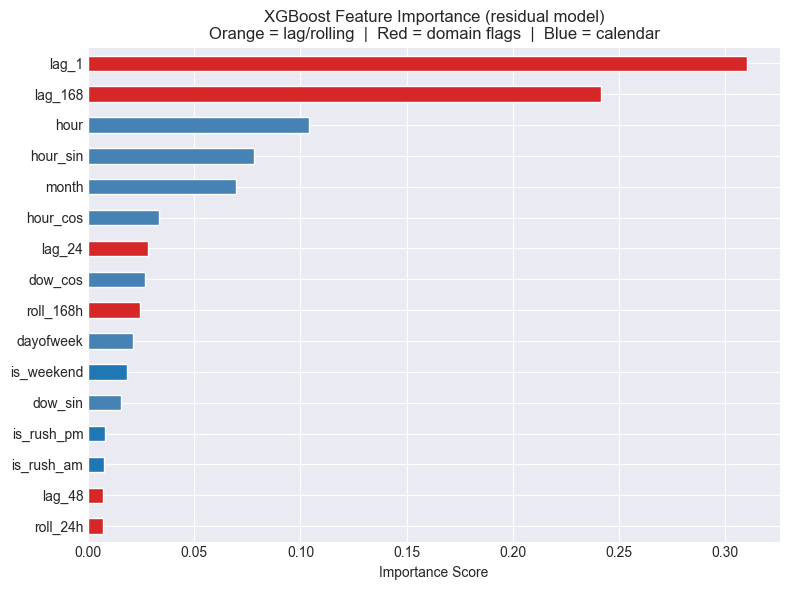


Top 5 features:
lag_1       0.310431
lag_168     0.241426
hour        0.103873
hour_sin    0.078035
month       0.069779


In [40]:
fi = pd.Series(xgb_f.feature_importances_, index=X_xgb.columns)
fi = fi.sort_values(ascending=True)   # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['C3' if 'lag' in n or 'roll' in n else
          'C0' if 'rush' in n or 'weekend' in n else 'steelblue'
          for n in fi.index]
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('XGBoost Feature Importance (residual model)\n'
             'Orange = lag/rolling  |  Red = domain flags  |  Blue = calendar')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

print('\nTop 5 features:')
print(fi.sort_values(ascending=False).head(5).to_string())

## Summary

| Component | Method | Key features |
|---|---|---|
| Trend | `LinearRegression` | `const`, `trend` (time step) |
| Daily seasonality | XGBoost (on residuals) | `hour`, `hour_sin/cos`, `is_rush_am/pm` |
| Weekly seasonality | XGBoost (on residuals) | `dayofweek`, `dow_sin/cos`, `is_weekend` |
| Monthly drift | XGBoost (on residuals) | `month` |
| Serial dependence | XGBoost (on residuals) | `lag_1`, `lag_24`, `lag_48`, `lag_168` |
| Smoothed momentum | XGBoost (on residuals) | `roll_24h`, `roll_168h` |

**Why hourly > daily:**  
Daily aggregation hides the strongest signal in the data — the intraday demand curve.  
Hourly data gives 24× more observations, makes the periodogram show two clear peaks,  
and allows meaningful lag features at natural ride-hailing intervals (1h, 24h, 168h).